# 08 — Brownfield change-impact agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/08_brownfield_change_impact_agent.ipynb)

Screen a new tie-in against hydraulics, separation, compression, utilities, emissions, and economics.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** baseline operating case, change composition and rate,
equipment limits, utilities, emissions factors, and economics.
**Outputs:** before/after capacity matrix, red flags, dependency list,
and minimum study scope.

Utilization is $U=x/x_{limit}$ and is classified green below 0.85,
amber from 0.85 to 1.0, and red above 1.0.

Deep dive: [external process optimization and brownfield packages](../../process/external_nonlinear_process_optimization.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
tiein_gas = {
    "methane": 0.760,
    "ethane": 0.090,
    "propane": 0.055,
    "n-butane": 0.025,
    "n-heptane": 0.035,
    "CO2": 0.025,
    "nitrogen": 0.010,
}
baseline_rate, tiein_rate = 70.0, 24.0
blended = {
    component: (
        baseline_rate * NORTHSTAR_GAS.get(component, 0.0)
        + tiein_rate * tiein_gas.get(component, 0.0)
    )
    / (baseline_rate + tiein_rate)
    for component in set(NORTHSTAR_GAS) | set(tiein_gas)
}
base_state = flash_state(NORTHSTAR_GAS, 80.0, 32.0)
change_state = flash_state(blended, 80.0, 32.0)
display(
    pd.DataFrame(
        [
            {
                "case": "baseline",
                "density_kg_m3": base_state["density_kg_m3"],
                "Z": base_state["z_factor"],
            },
            {
                "case": "with tie-in",
                "density_kg_m3": change_state["density_kg_m3"],
                "Z": change_state["z_factor"],
            },
        ]
    )
)


,case,density_kg_m3,Z
0,baseline,84.019038,0.806506
1,with tie-in,87.420995,0.797023


In [4]:
pipe_area_m2 = math.pi * 0.45**2 / 4.0

def capacity_case(rate_kg_s, state):
    velocity = rate_kg_s / state["density_kg_m3"] / pipe_area_m2
    rate_ratio = rate_kg_s / baseline_rate
    richness = state["molar_mass_kg_mol"] / base_state["molar_mass_kg_mol"]
    return {
        "export velocity": velocity / 14.0,
        "separator gas load": 0.80 * rate_ratio * math.sqrt(richness),
        "compressor power": 0.77 * rate_ratio * richness,
        "cooling utility": 0.68 * rate_ratio * richness,
        "relief screening load": 0.72 * rate_ratio,
    }

base_u = capacity_case(baseline_rate, base_state)
change_u = capacity_case(baseline_rate + tiein_rate, change_state)
capacity = pd.DataFrame(
    {
        "system": list(base_u),
        "baseline_utilization": list(base_u.values()),
        "change_utilization": list(change_u.values()),
    }
)
capacity["status"] = pd.cut(
    capacity.change_utilization,
    bins=[-np.inf, 0.85, 1.0, np.inf],
    labels=["green", "amber", "red"],
    right=False,
)
display(capacity)


,system,baseline_utilization,change_utilization,status
0,export velocity,0.374177,0.482913,green
1,separator gas load,0.800000,1.089045,red
2,compressor power,0.770000,1.062606,red
3,cooling utility,0.680000,0.938406,amber
4,relief screening load,0.720000,0.966857,amber


In [5]:
red_systems = capacity.query("status == 'red'").system.tolist()
amber_systems = capacity.query("status == 'amber'").system.tolist()
study_scope = []
if "separator gas load" in red_systems:
    study_scope.append("separator internals and carry-over rating")
if "compressor power" in red_systems:
    study_scope.append("compressor map, driver, and anti-surge study")
if any("relief" in name for name in red_systems + amber_systems):
    study_scope.append("scenario-based relief and flare verification")
study_scope.extend(["dynamic control interactions", "utilities and emissions update"])
decision_package = pd.DataFrame({"required_study": study_scope})
display(decision_package)


,required_study
0,separator internals and carry-over rating
1,"compressor map, driver, and anti-surge study"
2,scenario-based relief and flare verification
3,dynamic control interactions
4,utilities and emissions update


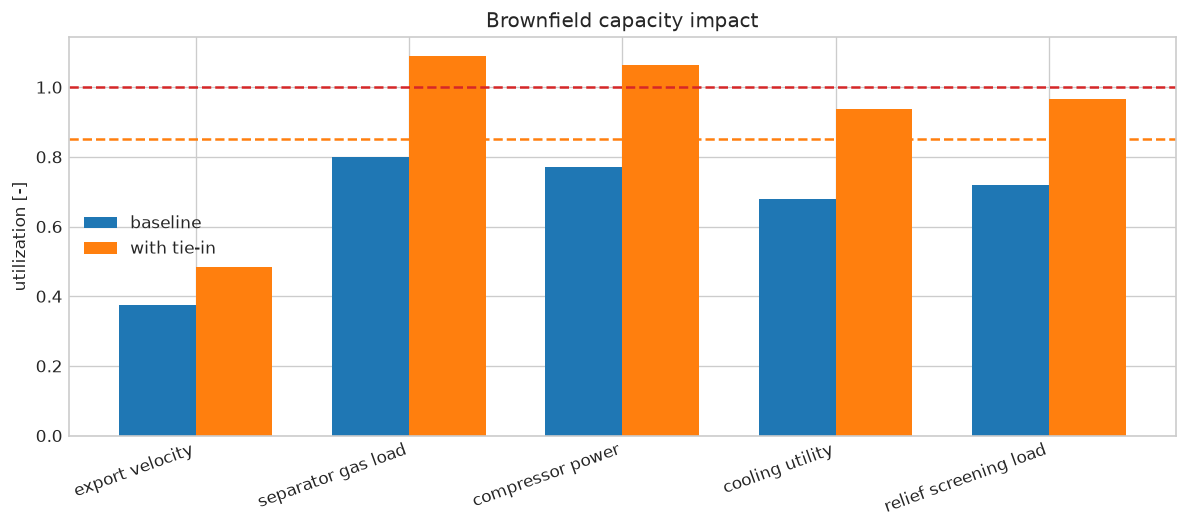

In [6]:
x = np.arange(len(capacity))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width / 2, capacity.baseline_utilization, width, label="baseline")
ax.bar(x + width / 2, capacity.change_utilization, width, label="with tie-in")
ax.axhline(0.85, color="tab:orange", linestyle="--")
ax.axhline(1.0, color="tab:red", linestyle="--")
ax.set_xticks(x, capacity.system, rotation=20, ha="right")
ax.set(ylabel="utilization [-]", title="Brownfield capacity impact")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
assert len(red_systems) >= 2
assert "separator gas load" in red_systems
assert "compressor power" in red_systems
print("VALIDATION PASSED")
print("Recommendation: do not approve the tie-in without the listed debottleneck studies.")


VALIDATION PASSED
Recommendation: do not approve the tie-in without the listed debottleneck studies.


## Interpretation and limits

The tie-in overloads separation and compression before detailed
dynamics are considered. Screen results define study scope, not final
equipment ratings; vendor curves, transient control, relief scenarios,
corrosion, layout, shutdown, and constructability still govern.
